# 06 - Monitoring du Data Drift en Production

## Objectif
Montrer comment le data drift est surveille sur le modele de scoring credit en comparant :
- un jeu de **reference** issu des donnees de preparation modele ;
- un jeu **courant** reconstruit a partir des requetes de production journalisees.

Ce notebook ne se limite pas a un guide : il **internalise la logique du script de monitoring**, execute l'analyse, genere le rapport Evidently, puis interprete les resultats obtenus.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from evidently import DataDefinition, Dataset, Report
from evidently.presets import DataDriftPreset
from IPython.display import FileLink, IFrame, Markdown, display
from sqlalchemy import create_engine, text

from credexp.config import settings
from credexp.data.io import load_parquet

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

## Chargement et preparation des donnees

La logique ci-dessous reprend directement le pipeline du monitoring :
- lecture du dataset de reference ;
- extraction des observations de production depuis PostgreSQL ;
- alignement des colonnes communes ;
- preparation explicite des types avant execution d'Evidently.

Le dernier point est important ici : certaines variables booleennes encodees provoquent des erreurs de calcul de quantiles dans Evidently. Elles sont donc converties en categories textuelles pour obtenir un rapport stable et reproductible.

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
OUTPUT_HTML = PROJECT_ROOT / "reports" / "monitoring" / "evidently_drift_notebook.html"
OUTPUT_META = PROJECT_ROOT / "reports" / "monitoring" / "evidently_drift_notebook_meta.json"
LIMIT = 5000


def _sanitize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df


def load_reference_dataframe() -> pd.DataFrame:
    ref_path = Path(settings.evidently_reference_path)
    if not ref_path.is_absolute():
        ref_path = settings.project_root / ref_path
    return _sanitize_dataframe(load_parquet(ref_path))


def load_current_dataframe(limit: int = 5000) -> pd.DataFrame:
    engine = create_engine(settings.database_url, pool_pre_ping=True)
    query = text(
        """
        SELECT created_at, input_payload
        FROM predictions
        WHERE status_code = 200
        ORDER BY created_at DESC
        LIMIT :limit
        """
    )

    with engine.connect() as conn:
        rows = conn.execute(query, {"limit": limit}).fetchall()

    if not rows:
        raise ValueError("No production prediction logs found in PostgreSQL.")

    items = []
    for row in rows:
        payload = row.input_payload
        features = dict(payload.get("features", {}))
        features["sk_id_curr"] = payload.get("sk_id_curr")
        features["created_at"] = row.created_at
        items.append(features)

    return _sanitize_dataframe(pd.DataFrame(items))


def align_reference_and_current(
    reference_df: pd.DataFrame,
    current_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ref = reference_df.copy()
    cur = current_df.copy()

    for col in ["TARGET", "created_at"]:
        if col in ref.columns:
            ref = ref.drop(columns=[col])
        if col in cur.columns:
            cur = cur.drop(columns=[col])

    common_cols = sorted(set(ref.columns).intersection(set(cur.columns)))
    if not common_cols:
        raise ValueError("No common columns between reference and current datasets.")

    return ref[common_cols], cur[common_cols]


def prepare_for_evidently(
    reference_df: pd.DataFrame,
    current_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ref = reference_df.copy()
    cur = current_df.copy()

    candidate_bool_cols = sorted(
        set(ref.select_dtypes(include=["bool", "boolean"]).columns)
        .union(set(cur.select_dtypes(include=["bool", "boolean"]).columns))
    )

    if candidate_bool_cols:
        ref[candidate_bool_cols] = ref[candidate_bool_cols].astype("string")
        cur[candidate_bool_cols] = cur[candidate_bool_cols].astype("string")

    leftover_ref = [col for col in ref.columns if str(ref[col].dtype) in {"bool", "boolean"}]
    leftover_cur = [col for col in cur.columns if str(cur[col].dtype) in {"bool", "boolean"}]
    if leftover_ref or leftover_cur:
        raise TypeError(
            f"Residual boolean columns remain after preparation: ref={leftover_ref}, cur={leftover_cur}"
        )

    return ref, cur


def infer_data_definition(reference_df: pd.DataFrame) -> DataDefinition:
    numerical_columns = []
    categorical_columns = []

    for col in reference_df.columns:
        if pd.api.types.is_numeric_dtype(reference_df[col].dtype):
            numerical_columns.append(col)
        else:
            categorical_columns.append(col)

    return DataDefinition(
        numerical_columns=numerical_columns,
        categorical_columns=categorical_columns,
    )


def build_drift_report(reference_df: pd.DataFrame, current_df: pd.DataFrame):
    data_definition = infer_data_definition(reference_df)
    report = Report([DataDriftPreset()])
    return report.run(
        reference_data=Dataset.from_pandas(reference_df, data_definition=data_definition),
        current_data=Dataset.from_pandas(current_df, data_definition=data_definition),
    )


def save_drift_report(report, output_html: Path, output_meta_json: Path, *, n_reference: int, n_current: int, n_features: int) -> None:
    output_html.parent.mkdir(parents=True, exist_ok=True)
    report.save_html(str(output_html))

    payload = {
        "n_reference": n_reference,
        "n_current": n_current,
        "n_features": n_features,
        "report_path": str(output_html),
    }
    output_meta_json.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def extract_drift_tables(
    report_dict: dict,
    *,
    n_reference: int,
    n_current: int,
    n_features: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    summary_metric = next(
        metric for metric in report_dict["metrics"]
        if metric["metric_name"].startswith("DriftedColumnsCount")
    )
    drifted_count = int(summary_metric["value"]["count"])
    drifted_share = float(summary_metric["value"]["share"])

    detail_rows = []
    for metric in report_dict["metrics"]:
        if not metric["metric_name"].startswith("ValueDrift("):
            continue
        detail_rows.append({
            "column": metric["config"]["column"],
            "method": metric["config"]["method"],
            "threshold": float(metric["config"]["threshold"]),
            "score": float(metric["value"]),
            "drift_detected": float(metric["value"]) > float(metric["config"]["threshold"]),
        })

    detail_df = pd.DataFrame(detail_rows).sort_values("score", ascending=False).reset_index(drop=True)
    summary_df = pd.DataFrame([
        {
            "observations_reference": n_reference,
            "observations_current": n_current,
            "features_communes": n_features,
            "variables_en_drift": drifted_count,
            "part_variables_en_drift": drifted_share,
        }
    ])
    return summary_df, detail_df


reference_df_raw = load_reference_dataframe()
current_df_raw = load_current_dataframe(limit=LIMIT)
reference_df_aligned, current_df_aligned = align_reference_and_current(reference_df_raw, current_df_raw)
reference_df_ready, current_df_ready = prepare_for_evidently(reference_df_aligned, current_df_aligned)
report = build_drift_report(reference_df_ready, current_df_ready)
report_dict = report.dict()
save_drift_report(
    report,
    output_html=OUTPUT_HTML,
    output_meta_json=OUTPUT_META,
    n_reference=len(reference_df_raw),
    n_current=len(current_df_raw),
    n_features=len(reference_df_aligned.columns),
)
summary_df, drift_details_df = extract_drift_tables(
    report_dict,
    n_reference=len(reference_df_raw),
    n_current=len(current_df_raw),
    n_features=len(reference_df_aligned.columns),
)

summary_df

{"ts": "2026-04-29T11:01:43Z", "level": "INFO", "name": "credexp.data.io", "msg": "load_parquet path=G:\\Mon Drive\\OC\\Projet_6\\credexp\\data\\processed\\reference.parquet"}


,observations_reference,observations_current,features_communes,variables_en_drift,part_variables_en_drift
0,20000,128,796,566,0.711055


## Verification du perimetre compare

Avant d'interpreter la derive, il faut verifier que les deux jeux compares sont coherents en volume, en nombre de colonnes communes et en types de variables.

In [3]:
schema_overview = pd.DataFrame([
    {
        "jeu": "reference_aligned",
        "lignes": len(reference_df_aligned),
        "colonnes": reference_df_aligned.shape[1],
        "float64": int((reference_df_aligned.dtypes == "float64").sum()),
        "int64": int((reference_df_aligned.dtypes == "int64").sum()),
        "bool": int((reference_df_aligned.dtypes == "bool").sum()),
        "object": int((reference_df_aligned.dtypes == "object").sum()),
    },
    {
        "jeu": "current_aligned",
        "lignes": len(current_df_aligned),
        "colonnes": current_df_aligned.shape[1],
        "float64": int((current_df_aligned.dtypes == "float64").sum()),
        "int64": int((current_df_aligned.dtypes == "int64").sum()),
        "bool": int((current_df_aligned.dtypes == "bool").sum()),
        "object": int((current_df_aligned.dtypes == "object").sum()),
    },
    {
        "jeu": "ready_for_evidently",
        "lignes": len(current_df_ready),
        "colonnes": current_df_ready.shape[1],
        "float64": int((current_df_ready.dtypes == "float64").sum()),
        "int64": int((current_df_ready.dtypes == "int64").sum()),
        "bool": int((current_df_ready.dtypes == "bool").sum()),
        "object": int((current_df_ready.dtypes == "object").sum()),
    },
])

schema_overview

,jeu,lignes,colonnes,float64,int64,bool,object
0,reference_aligned,20000,796,605,42,133,16
1,current_aligned,128,796,796,0,0,0
2,ready_for_evidently,128,796,663,0,0,0


In [4]:
missing_rate_comparison = pd.DataFrame({
    "missing_reference": reference_df_aligned.isna().mean(),
    "missing_current": current_df_aligned.isna().mean(),
}).assign(
    absolute_gap=lambda df: (df["missing_current"] - df["missing_reference"]).abs()
).sort_values("absolute_gap", ascending=False)

missing_rate_comparison.head(10)

,missing_reference,missing_current,absolute_gap
REG_REGION_NOT_LIVE_REGION,0.0,0.609375,0.609375
WEEKDAY_APPR_PROCESS_START_FRIDAY,0.0,0.609375,0.609375
OCCUPATION_TYPE_Laborers,0.0,0.609375,0.609375
OCCUPATION_TYPE_IT staff,0.0,0.609375,0.609375
WEEKDAY_APPR_PROCESS_START_WEDNESDAY,0.0,0.609375,0.609375
WEEKDAY_APPR_PROCESS_START_TUESDAY,0.0,0.609375,0.609375
WEEKDAY_APPR_PROCESS_START_THURSDAY,0.0,0.609375,0.609375
OCCUPATION_TYPE_High skill tech staff,0.0,0.609375,0.609375
WEEKDAY_APPR_PROCESS_START_SUNDAY,0.0,0.609375,0.609375
WEEKDAY_APPR_PROCESS_START_SATURDAY,0.0,0.609375,0.609375


## Synthese globale du drift

Evidently calcule un score de derive pour chaque variable puis estime la part de variables considerees comme driftes. Cette synthese donne la vue de pilotage principale.

In [5]:
summary_df.style.format({"part_variables_en_drift": "{:.1%}"})

,observations_reference,observations_current,features_communes,variables_en_drift,part_variables_en_drift
0,20000,128,796,566,71.1%


In [6]:
drift_details_df.head(15).style.format({"threshold": "{:.2f}", "score": "{:.3f}"})

,column,method,threshold,score,drift_detected
0,ACTIVE_AMT_CREDIT_MAX_OVERDUE_MEAN,Wasserstein distance (normed),0.10,3.773,True
1,CLOSED_AMT_CREDIT_SUM_DEBT_MAX,Wasserstein distance (normed),0.10,1.523,True
2,CLOSED_AMT_CREDIT_SUM_DEBT_SUM,Wasserstein distance (normed),0.10,1.498,True
3,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,Wasserstein distance (normed),0.10,1.275,True
4,ACTIVE_MONTHS_BALANCE_SIZE_MEAN,Wasserstein distance (normed),0.10,1.205,True
5,CLOSED_AMT_CREDIT_SUM_DEBT_MEAN,Wasserstein distance (normed),0.10,0.938,True
6,BURO_MONTHS_BALANCE_SIZE_MEAN,Wasserstein distance (normed),0.10,0.901,True
7,CC_AMT_CREDIT_LIMIT_ACTUAL_VAR,Wasserstein distance (normed),0.10,0.865,True
8,PREV_NAME_GOODS_CATEGORY_Vehicles_MEAN,Wasserstein distance (normed),0.10,0.833,True
9,NAME_INCOME_TYPE_Working,Jensen-Shannon distance,0.10,0.833,True


In [7]:
drift_count = int(summary_df.loc[0, "variables_en_drift"])
drift_share = float(summary_df.loc[0, "part_variables_en_drift"])
current_n = int(summary_df.loc[0, "observations_current"])
reference_n = int(summary_df.loc[0, "observations_reference"])

interpretation = f"""
### Interpretation des resultats

- Le rapport compare **{reference_n} observations de reference** a **{current_n} observations de production**.
- **{drift_count} variables sur {len(reference_df_aligned.columns)}**, soit **{drift_share:.1%}** des variables communes, sont detectees en drift.
- Le niveau de drift observe est **eleve** : la distribution du flux de production recent differe nettement de la base de reference.
- Cette lecture doit toutefois etre nuancee par la taille de l'echantillon courant, encore relativement reduite, ce qui peut amplifier l'instabilite sur certaines variables rares ou tres asymetriques.
- La surveillance reste utile : meme avec un volume courant limite, le signal est suffisamment fort pour justifier un suivi regulier et une verification des variables les plus touchees.
"""

display(Markdown(interpretation))


### Interpretation des resultats

- Le rapport compare **20000 observations de reference** a **128 observations de production**.
- **566 variables sur 796**, soit **71.1%** des variables communes, sont detectees en drift.
- Le niveau de drift observe est **eleve** : la distribution du flux de production recent differe nettement de la base de reference.
- Cette lecture doit toutefois etre nuancee par la taille de l'echantillon courant, encore relativement reduite, ce qui peut amplifier l'instabilite sur certaines variables rares ou tres asymetriques.
- La surveillance reste utile : meme avec un volume courant limite, le signal est suffisamment fort pour justifier un suivi regulier et une verification des variables les plus touchees.


## Visualisation ciblee des variables les plus driftees

Le tableau global est utile pour le pilotage, mais l'analyse devient plus concrete lorsqu'on observe la distribution de quelques variables fortement touchees.

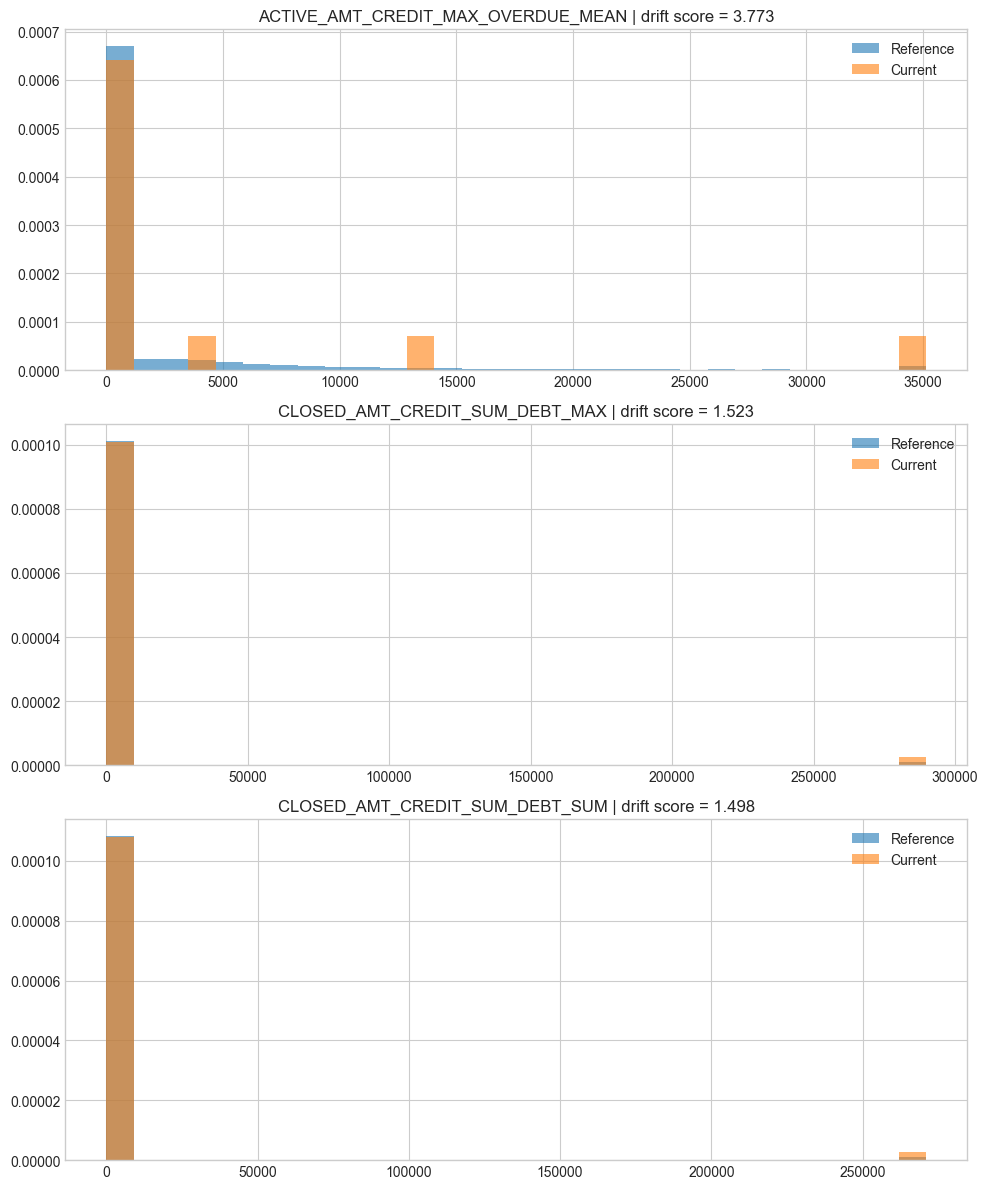

In [8]:
top_features = drift_details_df.loc[drift_details_df["drift_detected"], "column"].head(3).tolist()

fig, axes = plt.subplots(len(top_features), 1, figsize=(10, 4 * max(len(top_features), 1)))
if len(top_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, top_features):
    ref_series = reference_df_aligned[feature].dropna()
    cur_series = current_df_aligned[feature].dropna()
    combined = pd.concat([ref_series, cur_series], axis=0)

    if pd.api.types.is_numeric_dtype(combined):
        low, high = combined.quantile([0.01, 0.99]).tolist()
        ref_plot = ref_series.clip(lower=low, upper=high)
        cur_plot = cur_series.clip(lower=low, upper=high)
        ax.hist(ref_plot, bins=30, alpha=0.6, density=True, label="Reference")
        ax.hist(cur_plot, bins=30, alpha=0.6, density=True, label="Current")
    else:
        ref_counts = ref_series.astype("string").value_counts(normalize=True)
        cur_counts = cur_series.astype("string").value_counts(normalize=True)
        categories = ref_counts.index.union(cur_counts.index)[:12]
        x = np.arange(len(categories))
        width = 0.4
        ax.bar(x - width / 2, ref_counts.reindex(categories, fill_value=0.0), width=width, label="Reference")
        ax.bar(x + width / 2, cur_counts.reindex(categories, fill_value=0.0), width=width, label="Current")
        ax.set_xticks(x)
        ax.set_xticklabels(categories, rotation=45, ha="right")

    score = drift_details_df.loc[drift_details_df["column"] == feature, "score"].iloc[0]
    ax.set_title(f"{feature} | drift score = {score:.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

## Rapport Evidently interactif

Le rapport HTML complet est genere pendant l'execution du notebook. Il permet d'explorer le detail variable par variable, avec les visualisations et statistiques de drift fournies par Evidently.

In [9]:
display(FileLink(str(OUTPUT_HTML), result_html_prefix="Ouvrir le rapport HTML : "))
IFrame(src=str(OUTPUT_HTML), width="100%", height=900)

G:\Mon Drive\OC\Projet_6\credexp\reports\monitoring\evidently_drift_notebook.html

## Conclusion

Le monitoring de drift est desormais presente comme une **analyse complete** et non comme un simple mode d'emploi :
- la logique de generation du rapport est integree au notebook ;
- le rapport Evidently est produit et affiche ;
- les resultats sont synthetises puis interpretes.

Dans l'etat actuel des journaux de production, le signal de drift est marque. La priorite n'est donc pas seulement de continuer a surveiller, mais aussi de verifier si ce drift reflete un changement normal du trafic, un biais d'echantillonnage lie au faible volume courant, ou un ecart plus structurel entre donnees d'entrainement et donnees reellement servies en production.